#MATPLOTLIB

Chaque représentation graphique a une fonction correspondante avec Matplotlib :

- nuage de points ou scatter plot, en anglais :**scatter()** ;

- diagrammes en ligne ou en courbes :**plot()** ;

- diagrammes en barres :**bar()** ;

- histogrammes :**hist()** ;

- diagrammes circulaires :**pie()** .

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

## 1. Le nuage de points `scatter`

Les options de personnalisation :
- la couleur des points, via **color** ou **c** (nom, CSS étendu, HEX, RGB, ou cycle `'C0'`–`'C9'`) ;
- la taille des points, via l'argument **size** ou **s** (standard: 20 à 80, large: 100 à 200; exprimé en pt²);
- le type de marqueur via l'argument **marker** ;
- la transparence des points via l'argument **alpha** (compris entre 0 et 1).

### Choisir un marker sans se perdre

La doc liste 45 markers. En pratique 6-8 utilisé.
3 questions pour filter:

**1. Quel est le rôle sémantique du marker ?**
- Distinguer des catégories → formes géométriques distinctes
- Indiquer un point spécial (outlier, jalon) → marker fort et visible
- Scatter plot dense → petit marker discret, ou pas de marker

**2. Combien de séries à distinguer ?**
- ≤ 4 séries → marker + couleur suffisent
- 5–7 séries → combiner marker + couleur + linestyle
- \> 7 séries → problème de design, pas de marker

**3. Impression N&B ou écran couleur ?**
- Impression N&B → markers différents obligatoires
- Écran couleur → la couleur fait 80% du travail, le marker est secondaire

### Kit de survie (6 markers couvrent 95% des cas)

```python
MARKERS = {
    'défaut'    : 'o',   # cercle     — polyvalent
    'catégorie2': 's',   # carré      — distinct de o
    'catégorie3': '^',   # triangle   — distinct sans surcharge
    'catégorie4': 'D',   # diamant    — fort contraste
    'outlier'   : 'X',   # croix épaisse — attire l'œil
    'point_clé' : '*',   # étoile    — réservé aux annotations importantes
}
```


In [38]:
# chargement du fichier du cours libre openclassroom et visauliation de la structure du fichier avec head()
prets = pd.read_csv('https://raw.githubusercontent.com/OpenClassrooms-Student-Center/fr-4452741-decouvrez-les-librairies-python-pour-la-data-science/main/data/prets_final.csv')

prets.head()

,identifiant,ville,CP,revenu,remboursement,duree,type,taux_interet,taux_endettement,cout_total,benefices,risque
0,0,TOULOUSE,31100,3669.0,1130.05,240,immobilier,1.168,30.80,271212.0,131.99,Non
1,1,PARIS,75009,5310.0,240.00,64,automobile,3.701,4.52,15360.0,23.69,Non
2,1,PARIS,75009,5310.0,1247.85,300,immobilier,1.173,23.50,374355.0,182.97,Non
3,2,MARSEILLE,13010,1873.0,552.54,240,immobilier,0.972,29.50,132609.6,53.71,Non
4,3,MARSEILLE,13010,1684.0,586.03,180,immobilier,1.014,34.80,105485.4,44.57,Non


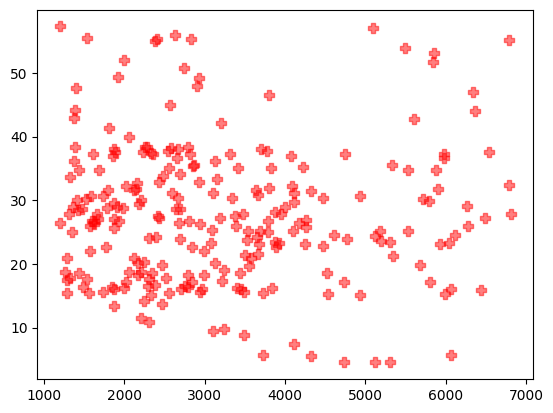

In [39]:
#Taux d'endettement en fonction du revenu
plt.scatter(prets['revenu'], prets['taux_endettement'],s=60, alpha=0.5, c='red', marker='P');


## 2. Le diagramme circulaire `pie`

Représente la contribution de chaque catégorie à un total. Pertinent uniquement si les parts s'additionnent à 100% et que les catégories sont peu nombreuses (≤ 6 idéalement).

Arguments principaux :
- **x** : les valeurs numériques agrégées
- **labels** : les étiquettes de chaque part
- **autopct** : pourcentages affichés à l'intérieur des parts — format `'%1.1f%%'`
- **startangle** : angle de départ — `90` pour commencer à 12h
- **explode** : liste de flottants de même longueur que le nombre de parts — détache une part du centre

Pour afficher les pourcentages à l'extérieur, utiliser une légende avec les valeurs calculées manuellement.

> ⚠️ Si une catégorie écrase les autres visuellement, un bar chart horizontal est plus honnête.

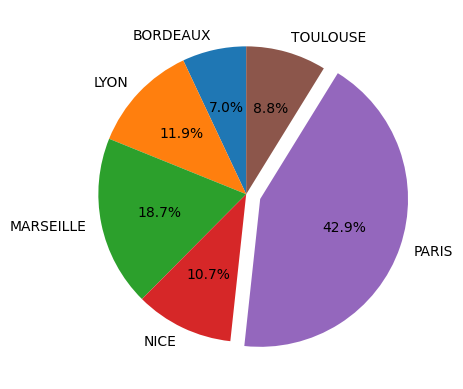

In [40]:
data = prets.groupby('ville')['remboursement'].sum()
data = data.reset_index() #pour passer de ville ccomme index à colonne ordinaire
plt.pie(x=data['remboursement'],
        labels=data['ville'],
        autopct='%1.1f%%',
        startangle=90,
        explode=[0,0,0,0,0.1,0]);

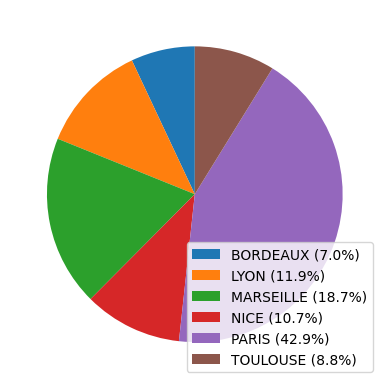

In [41]:
#Autre option avec une légende pour dégager l'intérieur du diagramme circulaire
data = prets.groupby('ville')['remboursement'].sum().reset_index()

total = data['remboursement'].sum()
labels_legende = [f"{v} ({r/total*100:.1f}%)"
                  for v, r in zip(data['ville'], data['remboursement'])]

plt.pie(x=data['remboursement'], startangle=90)
plt.legend(labels=labels_legende, loc='best');

## 3. Le diagramme en barres `bar` / `barh`

Représente des valeurs numériques par catégorie. À préférer au camembert dès que les catégories dépassent 6 ou qu'une valeur écrase les autres.

Arguments principaux :
- **x** (`bar`) / **y** (`barh`) : les catégories
- **height** (`bar`) / **width** (`barh`) : les valeurs numériques
- **width** (`bar`) / **height** (`barh`) : l'épaisseur des barres — défaut `0.8`
- **color** : couleur des barres — accepte une liste pour colorier chaque barre différemment
- **edgecolor** : couleur du contour des barres
- **bottom** : point de départ vertical — utilisé pour les **barres empilées**

> **`bottom`** : en passant les valeurs de la première série comme `bottom` de la seconde, les barres se superposent proprement.

> **`barh`** : préférer quand les étiquettes sont longues — elles s'affichent horizontalement sans rotation ni chevauchement.



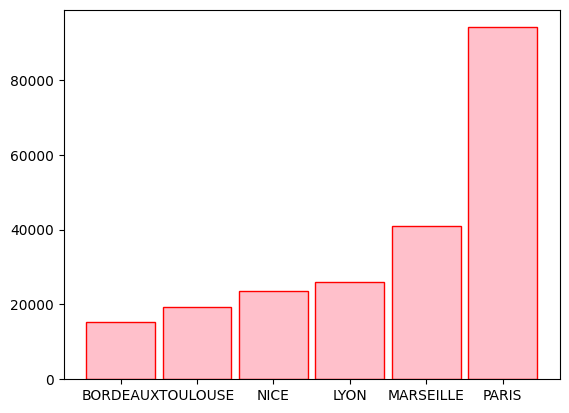

In [42]:
data_sorted = data.sort_values('remboursement', ascending=True)  # Peut trier le data frame en amont pour ordonner la serie
plt.bar(height=data_sorted['remboursement'],
        x=data_sorted['ville'],
        width=0.9,
        color='pink',
        edgecolor='red');

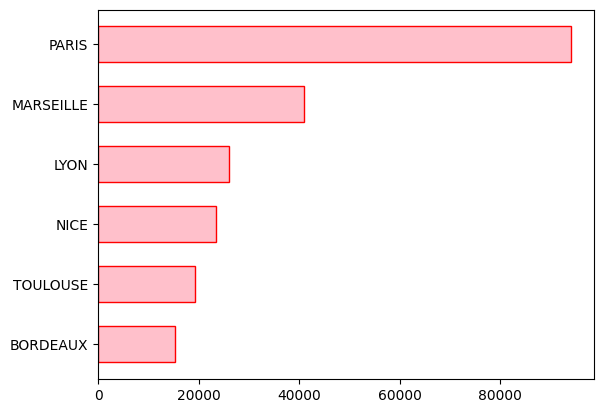

In [43]:
data_sorted = data.sort_values('remboursement', ascending=True)
plt.barh(y=data_sorted['ville'],
         width=data_sorted['remboursement'], #on inverse width et height
         height=0.6,
         color='pink',
         edgecolor='red');

## 4. L'histogramme `hist`

Représente la distribution d'une variable numérique continue. Matplotlib découpe automatiquement les valeurs en intervalles (bins) et compte les occurrences dans chacun.

Arguments principaux :
- **x** : la variable numérique à distribuer
- **bins** : nombre d'intervalles — défaut `10`, ajuster selon la densité des données
- **color** : couleur des barres
- **edgecolor** : contour des barres — recommandé pour distinguer les intervalles
- **density** : si `True`, affiche des fréquences relatives (somme = 1) au lieu des effectifs

Arguments de mise en forme (communs à tous les graphiques matplotlib) :
- **plt.title()** : titre du graphique
- **plt.xlabel()** / **plt.ylabel()** : titres des axes
- **plt.xticks()** / **plt.yticks()** : personnalisation des étiquettes d'axes
- **fontsize** : taille de la police
- **fontweight**='bold" : pour mettre en gras


**`bins`** est le paramètre le plus impactant : trop peu de bins écrase la distribution, trop de bins crée du bruit. Tester plusieurs valeurs avant de fixer.


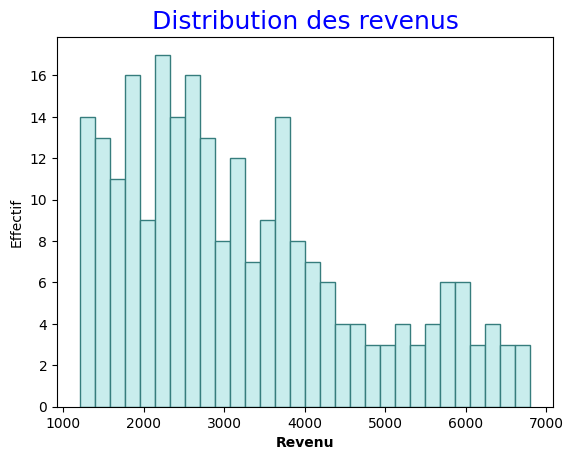

In [44]:
plt.hist(prets['revenu'], bins=30, color='#c9eded', edgecolor='#367d7d')
plt.title('Distribution des revenus', fontsize=18, color='blue')
plt.xlabel('Revenu', fontweight='bold')
plt.ylabel('Effectif');

## 5. Les courbes `plot`

Pour représenter une évolution, typiquement dans le temps.

Arguments principaux :
- **x**, **y** : les coordonnées des points
- **color** : couleur de la courbe
- **linestyle** : style de trait — `'-'` (continu), `'--'` (tirets), `'-.'` (mixte), `':'` (pointillés)
- **linewidth** : épaisseur du trait
- **marker** : symbole aux points de données — voir kit de survie section markers
- **label** : nom de la série — nécessaire pour afficher une légende avec `plt.legend()`

> Quand on trace plusieurs courbes sur le même graphique, `label` + `plt.legend()` deviennent indispensables.

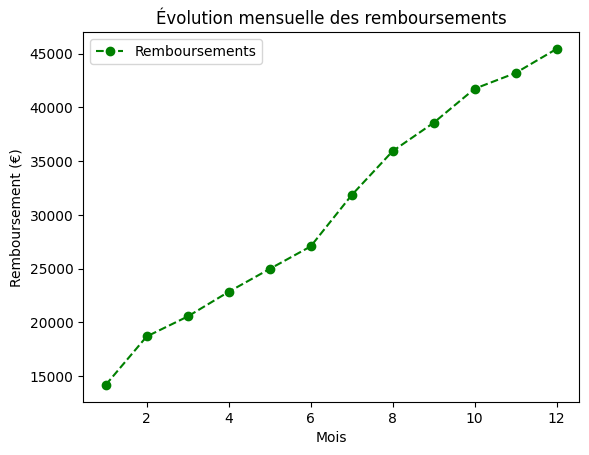

In [45]:
import numpy as np

# Série temporelle synthétique car absente dans le jeu de données utilisé
np.random.seed(42)
mois = np.arange(1, 13)
remboursements = np.cumsum(np.random.randint(1000, 5000, 12)) + 10000

plt.plot(mois, remboursements, marker='o', linestyle='--', color='green',
         linewidth=1.5, label='Remboursements')
plt.title('Évolution mensuelle des remboursements')
plt.xlabel('Mois')
plt.ylabel('Remboursement (€)')
plt.legend();

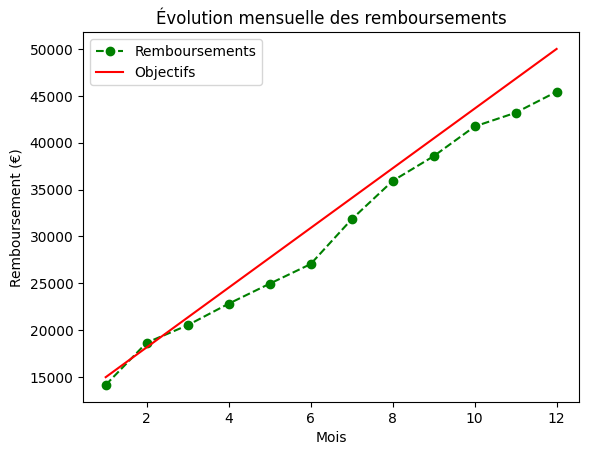

In [46]:
#Exemple avec 2 series
np.random.seed(42)
mois = np.arange(1, 13)
remboursements = np.cumsum(np.random.randint(1000, 5000, 12)) + 10000
objectifs = np.linspace(15000, 50000, 12)  # deuxième série

plt.plot(mois, remboursements, marker='o', linestyle='--', color='green', label='Remboursements')
plt.plot(mois, objectifs, linestyle='-', color='red', label='Objectifs')
plt.title('Évolution mensuelle des remboursements')
plt.xlabel('Mois')
plt.ylabel('Remboursement (€)')
plt.legend();

## 6. Plusieurs graphiques sur une même fenêtre `subplots`

`plt.subplots()` crée une grille de graphiques indépendants sur une même figure.

Arguments principaux :
- **nrows**, **ncols** : dimensions de la grille
- **figsize** : taille totale de la figure en pouces `(largeur, hauteur)`
- **sharex**, **sharey** : si `True`, impose la même échelle à tous les subplots — indispensable pour comparer honnêtement

`axes.flatten()` transforme la grille 2D en liste simple pour itérer dessus avec `enumerate`.

Sur chaque axe, les méthodes sont les mêmes que `plt.` mais préfixées par `axes[i].` :
- `axes[i].hist()`, `axes[i].scatter()`, `axes[i].plot()`...
- `axes[i].set_title()` : titre du subplot
- `axes[i].set_xlabel()` / `axes[i].set_ylabel()` : titres des axes

`plt.suptitle()` ajoute un titre global au-dessus de tous les subplots — distinct de `set_title()` qui titre chaque subplot individuellement.

`plt.tight_layout()` ajuste automatiquement les espaces entre subplots pour éviter les chevauchements.


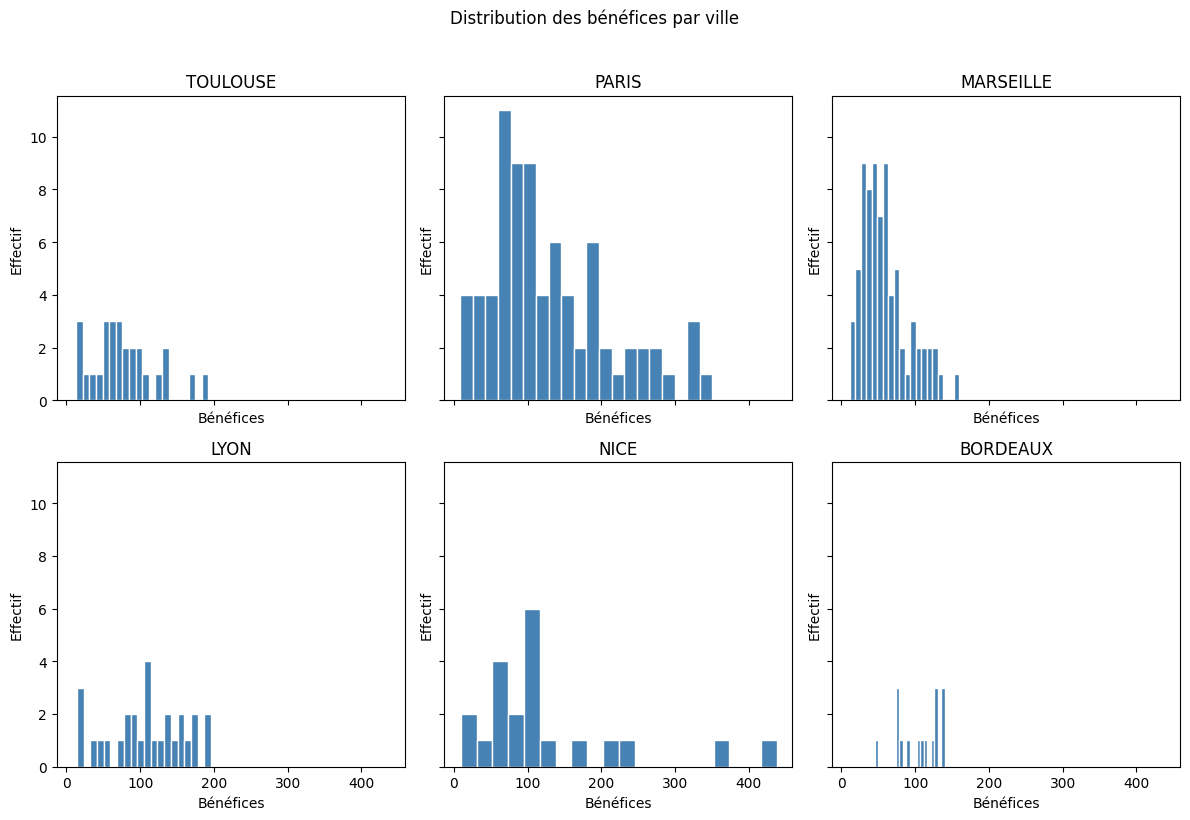

In [47]:
villes = prets['ville'].unique()
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, ville in enumerate(villes):
    subset = prets[prets['ville'] == ville]
    axes[i].hist(subset['benefices'], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(ville)
    axes[i].set_xlabel('Bénéfices')
    axes[i].set_ylabel('Effectif')

plt.suptitle('Distribution des bénéfices par ville', y=1.02)
plt.tight_layout();

## 7. Personnaliser les graphiques

Éléments externes :
- **title** : titre du graphique — accepte `fontsize` et `color`
- **legend** : légende des séries
- **xlabel** / **ylabel** : titres des axes — acceptent `fontsize` et `fontweight`

Éléments internes :
- **ylim** / **xlim** : limites des axes
- **yticks** / **xticks** : graduations manuelles
- **grid** : quadrillage — `axis='y'` pour horizontal uniquement
- **text(x, y, s)** : texte à une position précise du graphique
  - `x` : position horizontale (index de la barre)
  - `y` : position verticale (`hauteur_barre + décalage`)
  - `s` : texte — `round()` pour un entier, f-string pour formatage (`f"{val:,.0f} €"`)
  - kwargs :
     - `ha` :alignement horizontal : left,center, right
     - `va` : alignement vertical : bottom, center, top
     -`fontweight`: bold, light, heavy, black, semibold
     - + `fontsize`, `color`, `rotation`

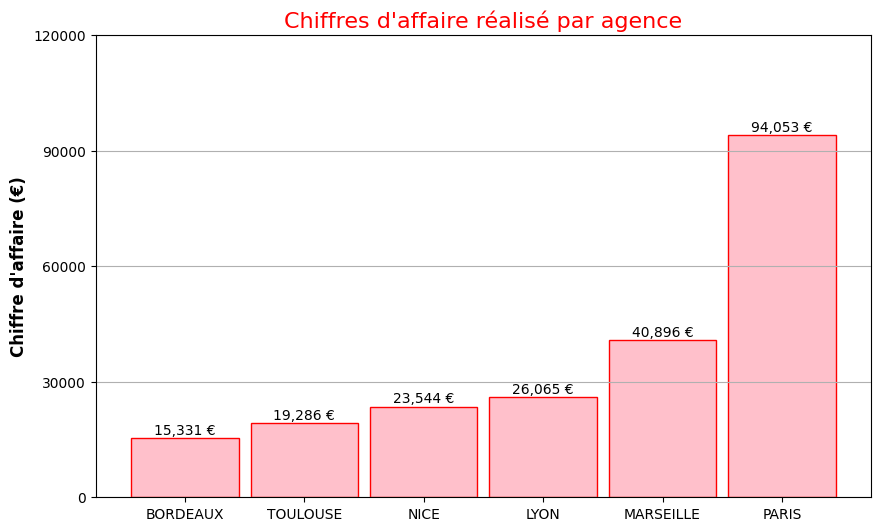

In [57]:
plt.figure(figsize=(10,6))

plt.bar(height=data_sorted['remboursement'],
        x=data_sorted['ville'],
        width=0.9,
        color='pink',
        edgecolor='red')
plt.title("Chiffres d'affaire réalisé par agence", fontsize=16, color='red')
plt.ylabel("Chiffre d'affaire (€)", fontsize=12, fontweight='bold')
plt.ylim(0, 120000)
plt.yticks([0, 30000, 60000, 90000, 120000])
plt.grid(axis='y')

ca = data_sorted['remboursement'].tolist()

for i in range(len(ca)):
    plt.text(i, ca[i] + 1000, f"{ca[i]:,.0f} €", ha='center')

plt.show()

## 8. Lignes de référence `axhline` / `axvline`

Tracent une ligne horizontale ou verticale sur un graphique — utile pour marquer une moyenne, un seuil, une valeur cible.

Arguments principaux :
- **y** (axhline) / **x** (axvline) : position de la ligne
- **color**, **linestyle**, **linewidth** : mise en forme
- **label** : pour l'inclure dans la légende



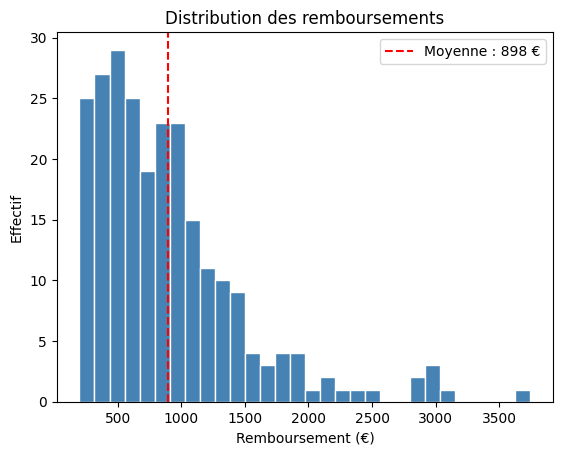

In [58]:

plt.hist(prets['remboursement'], bins=30, color='steelblue', edgecolor='white')
plt.axvline(x=prets['remboursement'].mean(),
            color='red',
            linestyle='--',
            linewidth=1.5,
            label=f"Moyenne : {prets['remboursement'].mean():,.0f} €")
plt.title('Distribution des remboursements')
plt.xlabel('Remboursement (€)')
plt.ylabel('Effectif')
plt.legend()
plt.savefig('distribution_remboursements.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Exporter un graphique `savefig`

À appeler avant `plt.show()` — après, la figure est vidée.

Arguments principaux :
- **fname** : nom du fichier avec extension — `.png`, `.jpg`, `.svg`, `.pdf`
- **dpi** : résolution en points par pouce — `150` pour usage web, `300` pour impression
- **bbox_inches** : `'tight'` pour éviter que les titres et labels soient coupés

> **Dans Colab**, `savefig` enregistre le fichier dans la session (pas sur ton ordinateur). Pour le récupérer localement, il faut ensuite le télécharger explicitement. L'ordre est impératif : `savefig` → `show` → `download`.



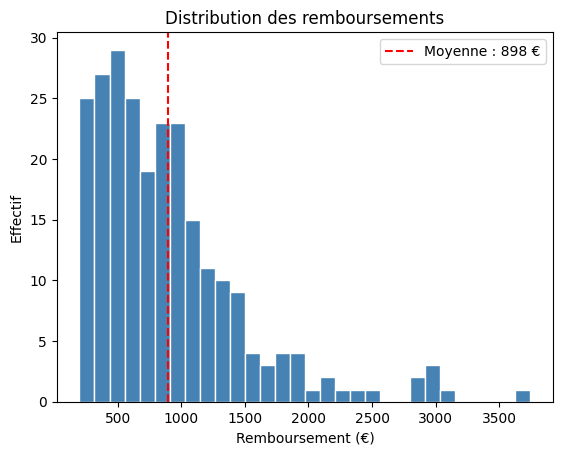

In [60]:
plt.hist(prets['remboursement'], bins=30, color='steelblue', edgecolor='white')
plt.axvline(x=prets['remboursement'].mean(),
            color='red',
            linestyle='--',
            linewidth=1.5,
            label=f"Moyenne : {prets['remboursement'].mean():,.0f} €")
plt.title('Distribution des remboursements')
plt.xlabel('Remboursement (€)')
plt.ylabel('Effectif')
plt.legend()
plt.savefig('distribution_remboursements.png', dpi=150, bbox_inches='tight')  # avant show
plt.show()

In [61]:
import os
os.path.exists('distribution_remboursements.png')

True

In [62]:
from google.colab import files
files.download('distribution_remboursements.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>